## Importando os dados preparados

In [1]:
import joblib

partitions, anomalyColumns = joblib.load("./dados_preparados.pkl")

## Importando os pipelines

In [2]:
pipelines = joblib.load("./pipelines.pkl")
print(list(pipelines))

['IF', 'OCSVM', 'LOF']


## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import roc_curve

from anomaly_utils import evaluateCandidates, evaluateQ95, extremeCases, scoreSummary, selectCandidate, transition

# Treinamento dos modelos

## Local Outlier Factor

Cada candidato de `n_neighbors` é ajustado somente com `normalTrain`, com `novelty=True`.
As APIs de novidade nunca pontuam as amostras do fit; o treino é descrito apenas por
`negative_outlier_factor_`. O q95 usa somente as True de validação. Fake-validation só
participa da escolha (ROC-AUC → AP → menor `n_neighbors`).

In [4]:
def describeLof(pipeline):
    detector = pipeline["detector"]
    fitLofFactor = -detector.negative_outlier_factor_
    if detector.n_neighbors_ != detector.n_neighbors:
        raise AssertionError("scikit-learn reduziu n_neighbors silenciosamente.")
    return {
        "n_neighbors": detector.n_neighbors,
        "offset": float(detector.offset_),
        "fitLofFactorQ95": float(np.quantile(fitLofFactor, 0.95)),
        "fitBelowOffsetFraction": float(np.mean(detector.negative_outlier_factor_ < detector.offset_)),
    }


fittedPipelines, validationResults = evaluateCandidates(
    pipelines["LOF"], partitions, anomalyColumns, describe=describeLof,
)
selectedModelKey = selectCandidate(validationResults, "n_neighbors")
display(validationResults.drop(columns=["nativeMetrics", "q95Metrics"]))
print("Candidato LOF congelado antes do teste:", selectedModelKey)

,modelKey,n_neighbors,offset,fitLofFactorQ95,fitBelowOffsetFraction,fitSeconds,q95Threshold,normalValidationQ95AlertRate,validationRocAuc,validationAveragePrecision
0,lof_neighbors_010,10,-1.5,1.333390,0.021296,0.046148,-0.129600,0.05,0.612166,0.808463
1,lof_neighbors_020,20,-1.5,1.325351,0.018981,0.047135,-0.162668,0.05,0.536334,0.779309
2,lof_neighbors_040,40,-1.5,1.410773,0.032407,0.048166,-0.127049,0.05,0.879816,0.904690
3,lof_neighbors_080,80,-1.5,1.489290,0.048148,0.088014,0.093838,0.05,0.974691,0.981207


Candidato LOF congelado antes do teste: lof_neighbors_080


## Avaliação no teste e comparação com Isolation Forest e One-Class SVM

Os controles usam exatamente o mesmo `normalTrain`, features, partições e regra q95.
O OCSVM é o candidato `nu=0.10`; nenhum controle é reajustado no teste.

In [5]:
results = {
    "lof": evaluateQ95(fittedPipelines[selectedModelKey], partitions, anomalyColumns, fit=False),
    "isolationForest": evaluateQ95(pipelines["IF"], partitions, anomalyColumns),
    "ocsvm": evaluateQ95(pipelines["OCSVM"]["ocsvm_nu_010"], partitions, anomalyColumns),
}

testPredictionsFrame = results["lof"]["testFrame"][["id", "label", "partition"] + anomalyColumns].copy()
for model, result in results.items():
    testPredictionsFrame[f"{model}AnomalyScore"] = result["scores"]
    testPredictionsFrame[f"{model}Q95IsAnomaly"] = result["q95Flags"]
testPredictionsFrame["lofNativeIsAnomaly"] = results["lof"]["nativeFlags"]

transitionPairs = {
    "lofVsIsolationForest": ("lof", "isolationForest"),
    "lofVsOcsvm": ("lof", "ocsvm"),
    "isolationForestVsOcsvm": ("isolationForest", "ocsvm"),
}
for column, (left, right) in transitionPairs.items():
    testPredictionsFrame[column] = transition(results[left]["q95Flags"], results[right]["q95Flags"], left, right)
transitionColumns = list(transitionPairs)

display(pd.DataFrame({
    f"{model} {rule}": result[f"{rule}Metrics"]
    for model, result in results.items() for rule in ["q95", "native"]
}).T)
display(pd.concat({
    model: scoreSummary(testPredictionsFrame, f"{model}AnomalyScore") for model in results
}, names=["model", "label"]))
testPredictionsFrame.groupby(["label"] + transitionColumns).size().rename("count").reset_index()

,rocAuc,averagePrecision,fakePrevalence,tn,fp,fn,tp,accuracy,precision,recall,f1,fpr
lof q95,0.987400,0.993869,0.714286,694.0,26.0,31.0,1769.0,0.977381,0.985515,0.982778,0.984145,0.036111
lof native,0.987400,0.993869,0.714286,692.0,28.0,30.0,1770.0,0.976984,0.984427,0.983333,0.983880,0.038889
isolationForest q95,0.980673,0.988672,0.714286,699.0,21.0,31.0,1769.0,0.979365,0.988268,0.982778,0.985515,0.029167
isolationForest native,0.980673,0.988672,0.714286,616.0,104.0,25.0,1775.0,0.948810,0.944651,0.986111,0.964936,0.144444
ocsvm q95,0.976384,0.985442,0.714286,693.0,27.0,145.0,1655.0,0.931746,0.983948,0.919444,0.950603,0.037500
ocsvm native,0.976384,0.985442,0.714286,650.0,70.0,25.0,1775.0,0.962302,0.962060,0.986111,0.973937,0.097222


class  count       mean     median       std       min  \
model           label                                                          
lof             0      True    720  -0.357812  -0.454499  0.475691 -0.541515   
                1      Fake   1800   3.506991   3.304370  1.399329 -0.528835   
isolationForest 0      True    720  -0.058204  -0.076152  0.061314 -0.125163   
                1      Fake   1800   0.148692   0.142426  0.037844 -0.124589   
ocsvm           0      True    720  -1.148508  -1.587920  2.789851 -3.769342   
                1      Fake   1800  10.892979  10.240216  5.719358 -3.779833   

                             max  
model           label             
lof             0       5.316613  
                1       6.717459  
isolationForest 0       0.212721  
                1       0.261826  
ocsvm           0      21.352744  
                1      23.014737

,label,lofVsIsolationForest,lofVsOcsvm,isolationForestVsOcsvm,count
0,0,alerta_adicionado_isolationForest,alerta_adicionado_ocsvm,alerta_mantido,1
1,0,alerta_adicionado_lof,alerta_adicionado_lof,sem_alerta,1
2,0,alerta_adicionado_lof,alerta_mantido,alerta_adicionado_ocsvm,5
3,0,alerta_mantido,alerta_mantido,alerta_mantido,20
4,0,sem_alerta,alerta_adicionado_ocsvm,alerta_adicionado_ocsvm,1
5,0,sem_alerta,sem_alerta,sem_alerta,692
6,1,alerta_mantido,alerta_adicionado_lof,alerta_adicionado_isolationForest,114
7,1,alerta_mantido,alerta_mantido,alerta_mantido,1655
8,1,sem_alerta,sem_alerta,sem_alerta,31


## Visualizações

As figuras são diagnósticas: não são importância de feature nem explicação causal.

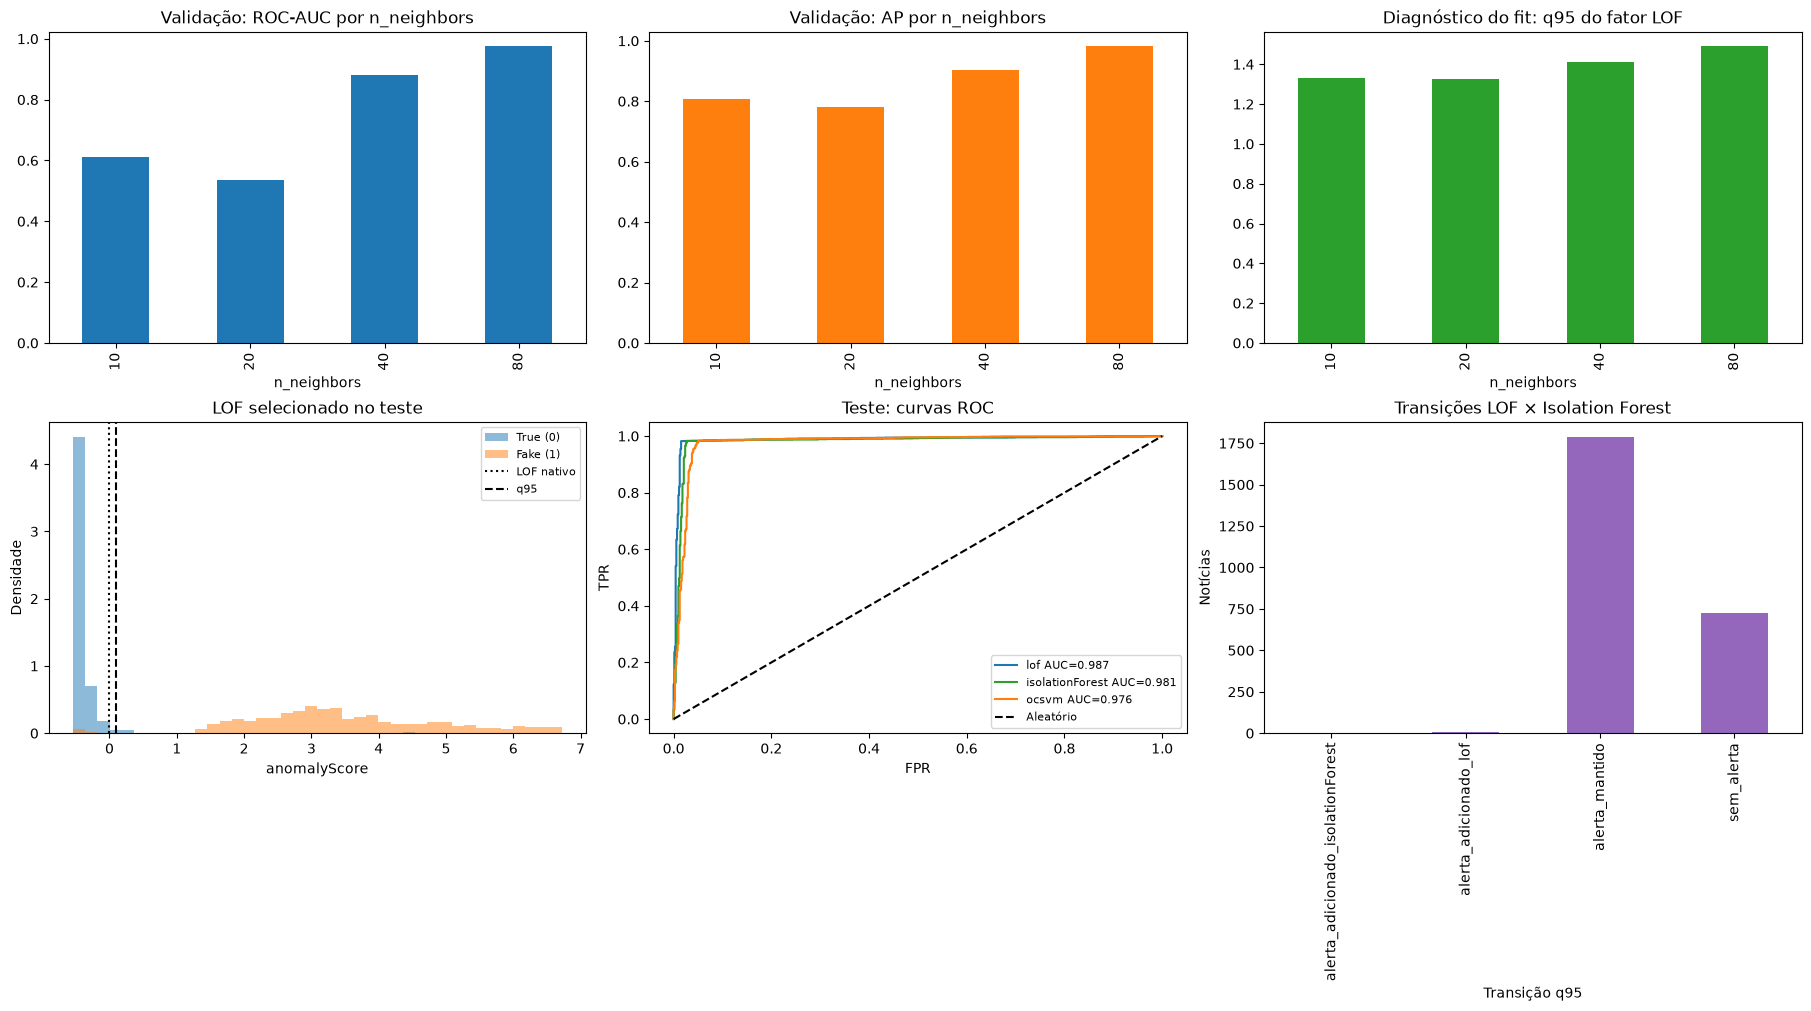

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for axis, column, title, color in [
    (axes[0, 0], "validationRocAuc", "Validação: ROC-AUC por n_neighbors", "tab:blue"),
    (axes[0, 1], "validationAveragePrecision", "Validação: AP por n_neighbors", "tab:orange"),
    (axes[0, 2], "fitLofFactorQ95", "Diagnóstico do fit: q95 do fator LOF", "tab:green"),
]:
    validationResults.plot(x="n_neighbors", y=column, kind="bar", ax=axis, title=title, legend=False, color=color)

testLabels = testPredictionsFrame["label"].to_numpy()
lofScores = testPredictionsFrame["lofAnomalyScore"].to_numpy()
scoreBins = np.histogram_bin_edges(lofScores, bins=40)
for label, name, color in [(0, "True (0)", "tab:blue"), (1, "Fake (1)", "tab:orange")]:
    axes[1, 0].hist(lofScores[testLabels == label], bins=scoreBins, density=True, alpha=0.5, label=name, color=color)
axes[1, 0].axvline(0, color="black", linestyle=":", label="LOF nativo")
axes[1, 0].axvline(results["lof"]["threshold"], color="black", linestyle="--", label="q95")
axes[1, 0].set(title="LOF selecionado no teste", xlabel="anomalyScore", ylabel="Densidade")
axes[1, 0].legend(fontsize=8)

for (model, result), color in zip(results.items(), ["tab:blue", "tab:green", "tab:orange"]):
    curveFpr, curveTpr, _ = roc_curve(testLabels, result["scores"])
    axes[1, 1].plot(curveFpr, curveTpr, label=f"{model} AUC={result['q95Metrics']['rocAuc']:.3f}", color=color)
axes[1, 1].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[1, 1].set(title="Teste: curvas ROC", xlabel="FPR", ylabel="TPR")
axes[1, 1].legend(fontsize=8)

testPredictionsFrame["lofVsIsolationForest"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 2], color="tab:purple", title="Transições LOF × Isolation Forest",
)
axes[1, 2].set(xlabel="Transição q95", ylabel="Notícias")
plt.show()

## Casos extremos e discordâncias

Calculados depois de congelar o candidato LOF, usando o teste apenas como avaliação exploratória.

In [7]:
exampleColumns = ["id", "label", "lofAnomalyScore", "lofNativeIsAnomaly", "lofQ95IsAnomaly"] + anomalyColumns
for title, examples in extremeCases(testPredictionsFrame, "lofAnomalyScore").items():
    display(Markdown(f"**{title}**"))
    display(examples[exampleColumns])

lofRank = testPredictionsFrame["lofAnomalyScore"].rank(ascending=False)
for control in ["isolationForest", "ocsvm"]:
    rankDifference = (lofRank - testPredictionsFrame[f"{control}AnomalyScore"].rank(ascending=False)).abs()
    display(Markdown(f"**LOF × {control}: maiores discordâncias de rank**"))
    display(
        testPredictionsFrame.assign(absoluteRankDifference=rankDifference)
        .nlargest(5, "absoluteRankDifference")[
            ["id", "label", "lofAnomalyScore", f"{control}AnomalyScore", "absoluteRankDifference"] + anomalyColumns
        ]
    )

**5 True mais anômalas**

,id,label,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,365t,0,5.316613,True,True,0,0.654545,0.0,0.181818,0.000000,0.800000
1,265t,0,4.506789,True,True,0,0.705882,0.0,0.098039,0.021739,0.782609
2,286t,0,4.364627,True,True,0,0.683333,0.0,0.166667,0.020000,0.820000
3,206t,0,3.198024,True,True,0,0.649123,0.0,0.175439,0.042553,0.787234
4,269t,0,2.941875,True,True,0,0.678571,0.0,0.196429,0.044444,0.844444


**5 Fake mais anômalas**

,id,label,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,3341,1,6.717459,True,True,0,0.690909,0.0,0.145455,0.0,0.808511
1,569,1,6.717459,True,True,0,0.690909,0.0,0.145455,0.0,0.808511
2,1937,1,6.715958,True,True,0,0.693548,0.0,0.145161,0.0,0.811321
3,1368,1,6.708444,True,True,0,0.685185,0.0,0.148148,0.0,0.804348
4,427,1,6.708444,True,True,0,0.685185,0.0,0.148148,0.0,0.804348


**5 Fake menos anômalas**

,id,label,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,38,1,-0.528835,False,False,1,0.690909,0.0,0.145455,0.000000,0.808511
1,19,1,-0.513361,False,False,1,0.764706,0.0,0.117647,0.000000,0.866667
2,1,1,-0.511970,False,False,1,0.683333,0.0,0.133333,0.019231,0.788462
3,26,1,-0.511010,False,False,1,0.706897,0.0,0.137931,0.000000,0.820000
4,67,1,-0.510018,False,False,1,0.714286,0.0,0.142857,0.000000,0.833333


**LOF × isolationForest: maiores discordâncias de rank**

,id,label,lofAnomalyScore,isolationForestAnomalyScore,absoluteRankDifference,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
2513,1005,1,1.373875,0.252990,1771.0,0,0.445946,0.0,0.283784,0.056604,0.622642
1414,411,1,1.450361,0.249528,1757.0,0,0.527273,0.0,0.163636,0.173913,0.630435
1326,2341,1,1.427245,0.241157,1755.0,0,0.477612,0.0,0.223881,0.076923,0.615385
2306,2450,1,1.450588,0.231504,1739.0,0,0.452830,0.0,0.169811,0.045455,0.545455
1606,1197,1,1.516274,0.238800,1738.0,0,0.549296,0.0,0.338028,0.085106,0.829787


**LOF × ocsvm: maiores discordâncias de rank**

,id,label,lofAnomalyScore,ocsvmAnomalyScore,absoluteRankDifference,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
2513,1005,1,1.373875,22.666645,1759.0,0,0.445946,0.0,0.283784,0.056604,0.622642
1414,411,1,1.450361,22.941375,1753.0,0,0.527273,0.0,0.163636,0.173913,0.630435
745,1394,1,1.375809,22.227215,1746.0,0,0.593220,0.0,0.237288,0.133333,0.777778
1557,2648,1,1.445299,22.635981,1746.0,0,0.636364,0.0,0.163636,0.173913,0.760870
2306,2450,1,1.450588,22.777089,1746.0,0,0.452830,0.0,0.169811,0.045455,0.545455


## Conclusão

In [8]:
selectedValidation = validationResults.set_index("modelKey").loc[selectedModelKey]
lofQ95 = results["lof"]["q95Metrics"]
display(Markdown(f"""
O candidato congelado foi **{selectedModelKey}**, com ROC-AUC de validação
**{selectedValidation['validationRocAuc']:.4f}** e AP **{selectedValidation['validationAveragePrecision']:.4f}**.
No teste, LOF q95 obteve ROC-AUC **{lofQ95['rocAuc']:.4f}**, AP **{lofQ95['averagePrecision']:.4f}**,
recall **{lofQ95['recall']:.2%}** e FPR **{lofQ95['fpr']:.2%}**.

O ajuste usou **{len(partitions['normalTrain'])} True e nenhuma Fake**. A seleção usou labels Fake
somente na validação. Estes números descrevem desvio linguístico neste split; não provam
falsidade nem superioridade estatística.
"""))


O candidato congelado foi **lof_neighbors_080**, com ROC-AUC de validação
**0.9747** e AP **0.9812**.
No teste, LOF q95 obteve ROC-AUC **0.9874**, AP **0.9939**,
recall **98.28%** e FPR **3.61%**.

O ajuste usou **2160 True e nenhuma Fake**. A seleção usou labels Fake
somente na validação. Estes números descrevem desvio linguístico neste split; não provam
falsidade nem superioridade estatística.
